In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
df = pd.read_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx")

## Self-reported reasons for voluntary termination

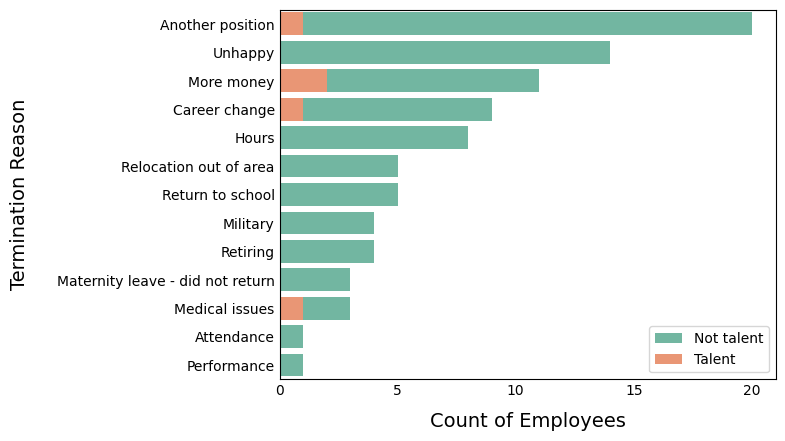

In [4]:
df["TermReason"] = df["TermReason"].astype(str).str.capitalize()

term = df[df["Termd"] == 1]
ct = pd.crosstab(term["TermReason"], [term["EmploymentStatus"], term["is_talent"]])

vol_counts = ct["Voluntarily Terminated"].fillna(0)
vol_counts["Total"] = vol_counts[0] + vol_counts[1]
vol_counts = vol_counts[vol_counts["Total"] > 0].sort_values("Total", ascending=False)

palette = sns.color_palette("Set2", n_colors=2)

sns.barplot(x=vol_counts["Total"], y=vol_counts.index, color=palette[0], label="Not talent")
sns.barplot(x=vol_counts[1], y=vol_counts.index, color=palette[1], label="Talent")

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

ax.grid(False)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

plt.xlabel("Count of Employees", fontsize=14, labelpad=10)
plt.ylabel("Termination Reason", fontsize=14, labelpad=20)

plt.legend()
plt.show()

In [5]:
df.columns

Index(['Employee.Name', 'PerfScore', 'PerformanceScore', 'GenderID', 'Salary',
       'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'MaritalDesc',
       'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire',
       'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department',
       'RecruitmentSource', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'ManPos',
       'TechLev', 'JobStr', 'ProjColl', 'ProjSelf', 'ProjLead', 'TeamIden',
       'OrgIden', 'CarOpp', 'PsySafe', 'Feedback', 'Trust', 'Network',
       'Remote', 'AIUse', 'AIConf', 'TrainHours', 'WLF', 'InnoCont',
       'technical_score', 'personal_score', 'interpersonal_score',
       'talent_score', 'is_talent'],
      dtype='object')

### TOP PREDICTORS OF TALENT
                 Feature  Importance
16            TrainHours    0.238037
15              InnoCont    0.170941
11                 AIUse    0.150328
7                 AIConf    0.115289
13               TechLev    0.086654
12  SpecialProjectsCount    0.060409
9               Feedback    0.021561
2               ProjSelf    0.020215
6               ProjLead    0.019272
0                 CarOpp    0.018938
3                  Trust    0.016121
10               Network    0.015965
1                OrgIden    0.015925
14                ManPos    0.015690
4               ProjColl    0.014967

### TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        50
           1       0.82      0.69      0.75        13

    accuracy                           0.90        63
   macro avg       0.87      0.83      0.85        63
weighted avg       0.90      0.90      0.90        63


Training Accura

/var/folders/b9/kg61r4ld3bldd20tdz24tnt80000gn/T/ipykernel_85791/1183793464.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


Text(0.5, 1.0, 'Which Variables Most Strongly Predict "Talent"?')

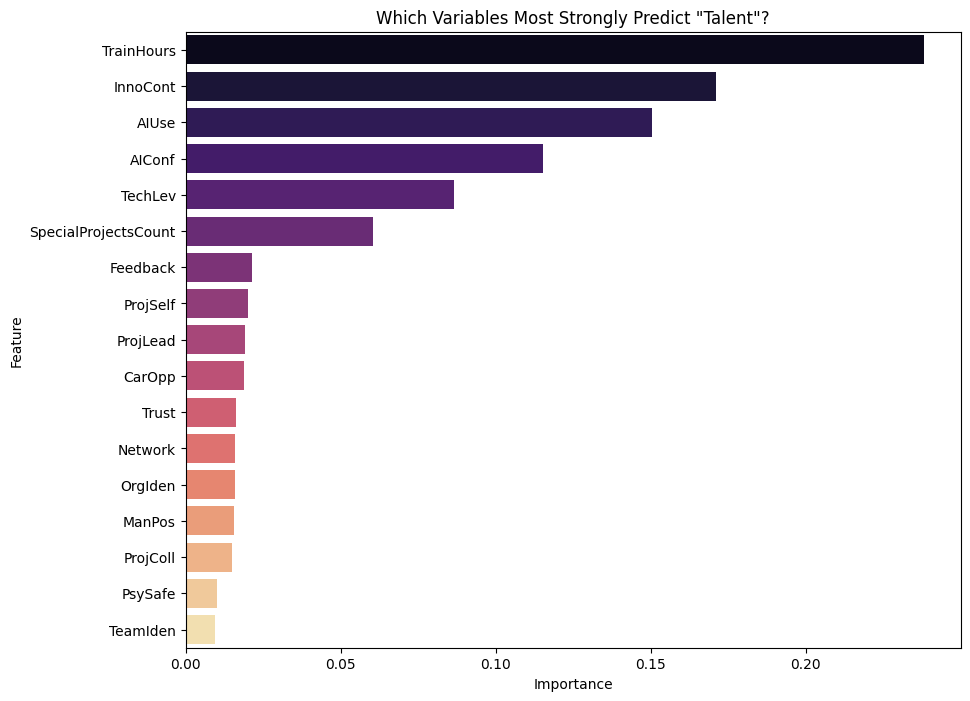

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Define features exactly as shown in your image
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours'
]

# 2. Data Preparation
# Target: is_talent | Features: The list above
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_talent']

# 3. Stratified Split
# This keeps the 'Talent' % identical in both Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

# 4. Build the Improved Pipeline
# 'SimpleImputer' fills missing values using medians from the training set
# 'RandomForestClassifier' uses balanced weights to handle the rare talent class
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=6,             # Stops the model from 'overfitting' (memorizing)
        class_weight='balanced', # Forces model to pay attention to 'Talent' group
        random_state=42
    ))
])

# 5. Train the Model
model_pipeline.fit(X_train, y_train)

# 6. Evaluate Performance
y_train_pred = model_pipeline.predict(X_train)
y_test_pred = model_pipeline.predict(X_test)

# Extracting Feature Importance for the "Coefficients" output
importances = model_pipeline.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- FINAL OUTPUTS ---

print("### TOP PREDICTORS OF TALENT")
print(importance_df.head(15))

print("\n### TEST SET CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred))

# Check for Overfitting
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Accuracy Gap:      {abs(train_acc - test_acc):.4f}")

# 7. Visualization of Important Variables
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Which Variables Most Strongly Predict "Talent"?')
#plt.show()

## Final Code for Random Forest on Voluntarily Terminated/Active Group Predictions

### TOP PREDICTORS OF EMPLOYMENT STATUS (Active vs Voluntarily Terminated)
                 Feature  Importance
0                 CarOpp    0.156296
1                OrgIden    0.091895
3                  Trust    0.088359
2               ProjSelf    0.087744
4               ProjColl    0.079272
16            TrainHours    0.072005
8                PsySafe    0.063047
6               ProjLead    0.061888
13               TechLev    0.059076
5               TeamIden    0.039429
9               Feedback    0.039074
7                 AIConf    0.035863
12  SpecialProjectsCount    0.030692
10               Network    0.030059
11                 AIUse    0.029861

### TEST SET CLASSIFICATION REPORT
                        precision    recall  f1-score   support

                Active       0.90      0.93      0.92        41
Voluntarily Terminated       0.82      0.78      0.80        18

              accuracy                           0.88        59
             macro avg       0.86      

/var/folders/b9/kg61r4ld3bldd20tdz24tnt80000gn/T/ipykernel_86258/319862455.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


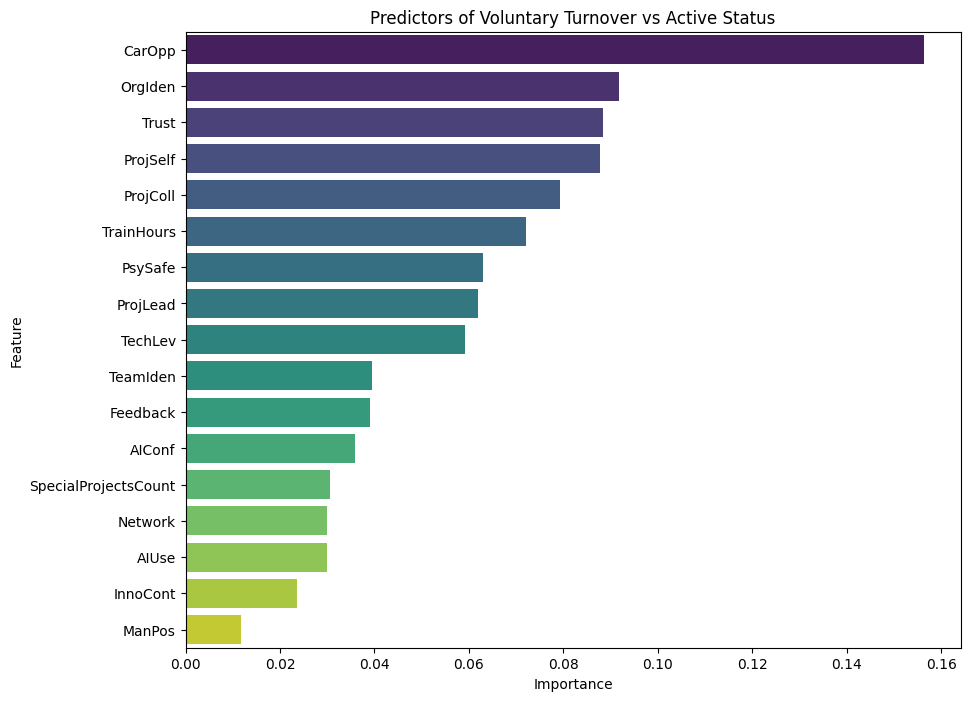

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# --- 1. Filter Data for Specific Statuses ---
# We only want 'Active' and 'Voluntarily Terminated'
target_statuses = ['Active', 'Voluntarily Terminated']
df_filtered = df[df['EmploymentStatus'].isin(target_statuses)].copy()

# --- 2. Define Features and Target ---
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours'
]

# Convert features to numeric (Dummies)
X = pd.get_dummies(df_filtered[features], drop_first=True)

# Target is now EmploymentStatus
y = df_filtered['EmploymentStatus']

# --- 3. Stratified Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Keeps the ratio of Active/Terminated consistent
)

# --- 4. Build the Pipeline ---
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=6, 
        class_weight='balanced', # Crucial if one status is more common than the other
        random_state=42
    ))
])

# --- 5. Train ---
model_pipeline.fit(X_train, y_train)

# --- 6. Evaluation ---
y_test_pred = model_pipeline.predict(X_test)

# Feature Importance
importances = model_pipeline.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- 7. Final Outputs ---

print("### TOP PREDICTORS OF EMPLOYMENT STATUS (Active vs Voluntarily Terminated)")
print(importance_df.head(15))

print("\n### TEST SET CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred))

# Accuracy Check
train_acc = accuracy_score(y_train, model_pipeline.predict(X_train))
test_acc = accuracy_score(y_test, y_test_pred)
print(f"\nTraining Accuracy: {train_acc:.4f} | Testing Accuracy: {test_acc:.4f}")

# Visualization
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Predictors of Voluntary Turnover vs Active Status')
plt.show()